# Internet of Things (IoT)

The Internet of Things (IoT) is a network of physical devices embedded with sensors, software, and connectivity that collect and exchange data over the internet. It enables everyday objects to interact with each other and cloud systems without human intervention, driving automation and real-time analytics.

Key Concepts

- Sensors and Actuators: Sensors collect real-world data (e.g., temperature, movement), while actuators carry out physical actions based on system commands.

- Connectivity: Devices communicate via Wi-Fi, Bluetooth, cellular (e.g., 5G/LTE), or low-power wide-area networks (LPWAN).

- Cloud Processing: Data is sent to the cloud, where it is analyzed to trigger automated responses or provide actionable insights.

Common Applications

- Consumer IoT: Personal devices like smartwatches, smart speakers, and connected home security systems.

- Industrial IoT (IIoT): Manufacturing machinery, smart grid energy monitors, and connected logistics systems to improve production and reduce downtime.

- Commercial IoT: Healthcare tools (e.g., remote patient monitors), smart traffic management, and retail tracking systems.


# Integrating IoT and Machine Learning for Architecture Design

Integrating IoT and machine learning (ML) creates self-optimizing building systems.

IoT sensors capture real-time data on temperature, occupancy, and equipment health. ML algorithms process this data to automate HVAC, predict equipment failures before they occur, and adjust settings based on historical user behavior, drastically cutting energy costs.

Key applications of IoT and ML in smart buildings include:

- Predictive Maintenance: ML models analyze vibration and temperature data from IoT sensors to forecast equipment breakdowns, preventing costly downtime.

- Energy Management: AI systems evaluate occupancy trends and weather forecasts to pre-cool or pre-heat zones, significantly lowering utility bills.

- Space Utilization: Occupancy sensors track foot traffic, allowing facility managers to reconfigure layouts and improve real estate efficiency.

- Security & Access Control: AI-enabled cameras and biometric IoT devices monitor restricted areas, flagging anomalies or unauthorized entry in real-time

# Predictive Maintenance for Building Architecture

- Predictive maintenance and energy efficiency transform static building management systems (BMS) into dynamic, self-optimizing ecosystems.

- By combining IoT sensor telemetry with machine learning (ML) architectures, facilities transition from reactive firefighting to proactive, data-driven orchestration.

- Predictive maintenance uses real-time telemetry to anticipate asset failures, replacing rigid calendar-based schedules with condition-based interventions.

## System Architecture & Data Pipelines

The deployment follows a highly structured edge-to-cloud data ingestion and processing pipeline:

- Sensor Ingestion Layer: Specialized IoT nodes capture continuous physical metrics from critical structural and mechanical assets.

- Edge Processing: Local gateways perform high-frequency fast Fourier transforms (FFT) on vibration data, filtering high-frequency noise before cloud transmission.

- Central Cloud Data Lake: Time-series databases store aggregated telemetry alongside historical maintenance logs (Computerized Maintenance Management Systems - CMMS).

- ML Inference Pipeline: Scheduled microservices run predictive algorithms against arriving data windows to flag statistical anomalies.

## Core Equipment & Target

VariablesPredictive maintenance targets the mechanical core of building infrastructure:

- HVAC Chillers & Compressors: Monitors refrigerant pressure, oil temperature, and motor current draw to flag internal valve leaks or compressor friction.

- Air Handling Units (AHUs): Tracks differential pressure across particulate filters and fan belt vibration profiles to predict static failure.

- Water Pumps & Piping: Monitors acoustic emissions and flow rate degradation to isolate cavitation risks or hairline pipe fractures.

- Elevator Traction Motors: Captures angular velocity variances and thermal profiles to identify bearing wear before mechanical seizure occurs.

## Machine Learning Frameworks

Data scientists deploy specialized ML models depending on the target asset and data structure:

- Anomaly Detection: Algorithms like Isolation Forests or One-Class Support Vector Machines (SVM) establish a dynamic baseline of "healthy" asset operation. They flag deviations without requiring labeled historical failure data.

- Time-to-Failure (RUL) Estimation: Long Short-Term Memory (LSTM) networks and gated recurrent units (GRUs) process historical sequence data to predict the Remaining Useful Life (RUL) of a degrading component.

- Classification & Fault Diagnostics: If a failure is imminent, Random Forests or Gradient Boosted Trees (XGBoost) classify the specific root cause (e.g., misalignment vs. unbalance) based on past failure signatures.

# Implementation
This Python implementation builds an end-to-end anomaly detection pipeline using scikit-learn's Isolation Forest algorithm to process HVAC chiller sensor data. The script generates synthetic IoT telemetry (vibration and temperature) and isolates operational anomalies.

=== MODEL ANALYSIS RESULTS ===
Is_Anomaly
False    950
True      50
Name: count, dtype: int64

=== FIRST 5 FLAGGED ANOMALIES (CRITICAL EVENTS) ===
                     Vibration_mm_s  Temperature_C
Timestamp                                         
2026-01-01 01:03:00        2.280810      80.642186
2026-01-01 01:11:00        4.114810      88.620024
2026-01-01 01:56:00        3.779021      99.680762
2026-01-01 02:14:00        3.413090      87.982756
2026-01-01 02:21:00        3.771298      96.762003


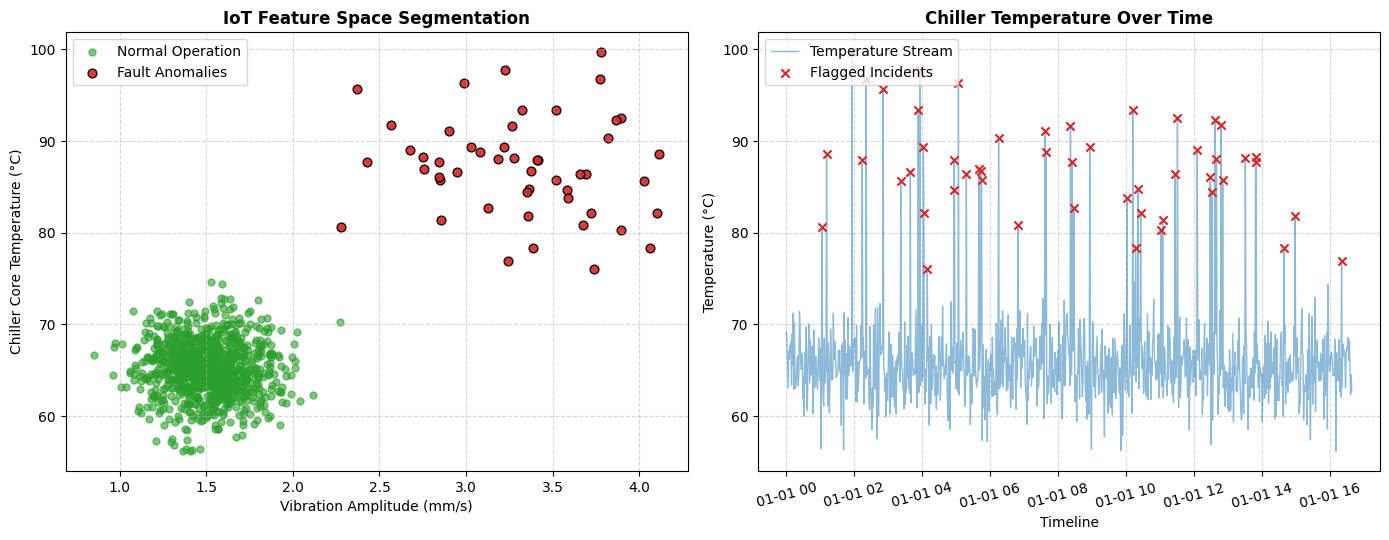

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 1. Generate Synthetic IoT Sensor Data (HVAC Chiller Vibration & Temperature)
np.random.seed(42)
n_samples = 1000

# Normal operational data distribution
normal_vibration = np.random.normal(loc=1.5, scale=0.2, size=n_samples) # mm/s
normal_temp = np.random.normal(loc=65, scale=3, size=n_samples)        # Celsius

# Inject anomalies (simulating bearing wear or compressor overheating)
n_anomalies = 50
anomaly_indices = np.random.choice(n_samples, size=n_anomalies, replace=False)
normal_vibration[anomaly_indices] += np.random.uniform(1.0, 2.5, size=n_anomalies)
normal_temp[anomaly_indices] += np.random.uniform(15, 30, size=n_anomalies)

# Assemble DataFrame
timestamps = pd.date_range(start="2026-01-01", periods=n_samples, freq="min")
df = pd.DataFrame({
    "Timestamp": timestamps,
    "Vibration_mm_s": normal_vibration,
    "Temperature_C": normal_temp
})
df.set_index("Timestamp", inplace=True)

# 2. Train Isolation Forest Model
features = ["Vibration_mm_s", "Temperature_C"]
X = df[features]

# contamination=0.05 specifies an expected 5% anomaly rate
model = IsolationForest(contamination=0.05, random_state=42)
df["Anomaly_Score"] = model.fit_predict(X)

# Map outputs: scikit-learn uses -1 for anomalies and 1 for normal data
df["Is_Anomaly"] = df["Anomaly_Score"].map({1: False, -1: True})

# =====================================================================
# 3. EXPLICIT OUTPUT TERMINAL PRINT STATEMENTS
# =====================================================================
print("=== MODEL ANALYSIS RESULTS ===")
print(df["Is_Anomaly"].value_counts())
print("\n=== FIRST 5 FLAGGED ANOMALIES (CRITICAL EVENTS) ===")
print(df[df["Is_Anomaly"]][features].head())

# =====================================================================
# 4. LOCAL PLOTTING BLOCK (Generates UI pop-up window)
# =====================================================================
normal_data = df[~df["Is_Anomaly"]]
anomalies = df[df["Is_Anomaly"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: Feature Space Scatter Map
ax1.scatter(normal_data["Vibration_mm_s"], normal_data["Temperature_C"], c="#2ca02c", alpha=0.6, label="Normal Operation", s=25)
ax1.scatter(anomalies["Vibration_mm_s"], anomalies["Temperature_C"], c="#d62728", alpha=0.9, label="Fault Anomalies", edgecolors="black", s=40)
ax1.set_title("IoT Feature Space Segmentation", fontsize=12, fontweight="bold")
ax1.set_xlabel("Vibration Amplitude (mm/s)")
ax1.set_ylabel("Chiller Core Temperature (°C)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# Plot 2: Time-Series Stream Trace
ax2.plot(df.index, df["Temperature_C"], c="#1f77b4", alpha=0.5, label="Temperature Stream", linewidth=1)
ax2.scatter(anomalies.index, anomalies["Temperature_C"], c="#d62728", marker="x", s=35, zorder=5, label="Flagged Incidents")
ax2.set_title("Chiller Temperature Over Time", fontsize=12, fontweight="bold")
ax2.set_xlabel("Timeline")
ax2.set_ylabel("Temperature (°C)")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show() # Triggers local frame display window

### In the next cell, we will rewrite the above model to handle streaming real-time calculations using standard Kafka/MQTT topics

To handle real-time streaming calculations, the batch processing script must be refactored into a continuous consumer-producer loop.In an enterprise smart building setup, an edge device publishes raw sensor data to an MQTT (Message Queuing Telemetry Transport) broker (lightweight protocol for IoT). A bridge worker or service routes this data to Apache Kafka for durable streaming ingestion, where an ML script consumes the stream, runs real-time inference, and publishes alerts back to an anomaly topic.



In [ ]:
import json
import logging
from paho.mqtt import client as mqtt_client
from kafka import KafkaConsumer, KafkaProducer
import numpy as np
from sklearn.ensemble import IsolationForest

# Configure logging pipeline for the facility management desk
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("SmartBuildingML")

# =====================================================================
# 1. CORE MACHINE LEARNING ENGINE (PRE-TRAINED BASELINE)
# =====================================================================
def initialize_pretrained_model():
    """
    In streaming systems, models are trained offline on historical data
    and loaded into memory for real-time, low-latency scoring.
    """
    np.random.seed(42)
    # Generate reference healthy operating envelope
    ref_vibration = np.random.normal(loc=1.5, scale=0.2, size=5000)
    ref_temp = np.random.normal(loc=65, scale=3, size=5000)
    X_train = np.column_stack((ref_vibration, ref_temp))

    # Instantiate and fit the isolation forest
    model = IsolationForest(contamination=0.01, random_state=42)
    model.fit(X_train)
    logger.info("Baseline machine learning model initialized and primed.")
    return model

# Initialize the model instance globally for the stream loops
ml_model = initialize_pretrained_model()

# =====================================================================
# 2. OPTION A: REAL-TIME MQTT CONSUMER (Lightweight Edge Deployment)
# =====================================================================
MQTT_BROKER = "mqtt.smartbuilding.local"
MQTT_PORT = 1883
MQTT_SUB_TOPIC = "building/chiller/telemetry"
MQTT_ALERT_TOPIC = "building/chiller/alerts"

def on_mqtt_message(client, userdata, msg):
    try:
        # Parse payload from the physical edge node
        payload = json.loads(msg.payload.decode())
        vibration = float(payload["vibration_mm_s"])
        temperature = float(payload["temperature_C"])
        asset_id = payload.get("asset_id", "CHILLER_01")

        # Format payload matrix for prediction: shape (1, n_features)
        input_data = np.array([[vibration, temperature]])

        # Run real-time unsupervised isolation grading
        # predict() returns -1 for anomalous variance, 1 for nominal state
        prediction = ml_model.predict(input_data)[0]
        anomaly_score = ml_model.score_samples(input_data)[0] # Raw anomaly metrics

        if prediction == -1:
            alert_payload = {
                "asset_id": asset_id,
                "status": "CRITICAL_ANOMALY",
                "severity": "HIGH",
                "metrics": {"vibration": vibration, "temperature": temperature},
                "score": float(anomaly_score)
            }
            # Publish actionable intervention alert back to the broker
            client.publish(MQTT_ALERT_TOPIC, json.dumps(alert_payload), qos=1)
            logger.warning(f"🚨 ANOMALY DETECTED on asset {asset_id}! Alert dispatched.")

    except Exception as e:
        logger.error(f"Failed to process streaming MQTT payload: {str(e)}")

def run_mqtt_streaming_pipeline():
    """Initializes a non-blocking background network loop for continuous monitoring."""
    client = mqtt_client.Client(client_id="Building_Analytics_Engine")
    client.on_message = on_mqtt_message

    try:
        client.connect(MQTT_BROKER, MQTT_PORT, keepalive=60)
        client.subscribe(MQTT_SUB_TOPIC, qos=1)
        logger.info(f"Connected to MQTT broker. Subscribed to stream: {MQTT_SUB_TOPIC}")
        client.loop_forever() # Blocks loop to hold open the real-time worker execution
    except Exception as e:
        logger.critical(f"MQTT Broker pipeline failure: {str(e)}")

# =====================================================================
# 3. OPTION B: REAL-TIME KAFKA STREAM WORKER (Enterprise Scale Data Lake)
# =====================================================================
KAFKA_BOOTSTRAP_SERVERS = ["kafka-cluster-01.local:9092"]
KAFKA_INPUT_TOPIC = "chiller-telemetry"
KAFKA_ALERT_TOPIC = "chiller-alerts"

def run_kafka_streaming_pipeline():
    """Consumes telemetry chunks from a cluster topic and forwards anomalous footprints."""
    try:
        # Instantiate durable cluster consumer
        consumer = KafkaConsumer(
            KAFKA_INPUT_TOPIC,
            bootstrap_servers=KAFKA_BOOTSTRAP_SERVERS,
            value_deserializer=lambda x: json.loads(x.decode("utf-8")),
            auto_offset_reset="latest",
            group_id="bms-analytics-group"
        )

        # Instantiate messaging producer to pass alerts forward to CMMS hooks
        producer = KafkaProducer(
            bootstrap_servers=KAFKA_BOOTSTRAP_SERVERS,
            value_serializer=lambda v: json.dumps(v).encode("utf-8")
        )

        logger.info(f"Kafka consumer engine initialized. Listening on topic: {KAFKA_INPUT_TOPIC}")

        # Continuous long-polling worker engine loop
        for message in consumer:
            data = message.value
            vibration = float(data["vibration_mm_s"])
            temperature = float(data["temperature_C"])
            asset_id = data.get("asset_id", "CHILLER_UNKNOWN")

            # Vectorize metrics for memory inference matrix calculation
            input_vector = np.array([[vibration, temperature]])
            prediction = ml_model.predict(input_vector)[0]

            if prediction == -1:
                anomaly_alert = {
                    "event": "PREDICTIVE_MAINTENANCE_ALERT",
                    "target_node": asset_id,
                    "telemetry_snapshot": {"vibration": vibration, "temperature": temperature},
                    "action_required": "SCHEDULE_FIELD_INSPECTION"
                }
                # Broadcast back onto the cluster for execution applications (e.g., Twilio/Slack alerts)
                producer.send(KAFKA_ALERT_TOPIC, value=anomaly_alert)
                producer.flush()
                logger.warning(f"⚠️ [Kafka Alert] Isolated structural deviation on machine: {asset_id}")

    except Exception as e:
        logger.critical(f"Catastrophic Kafka streaming pipeline termination: {str(e)}")

# =====================================================================
# 4. EXECUTION SWITCHBOARD ENTRYPOINT
# =====================================================================
if __name__ == "__main__":
    # Choose execution paradigm based on your network architecture:
    # To use MQTT edge configuration:
    # run_mqtt_streaming_pipeline()

    # To use Enterprise Kafka Cluster infrastructure:
    run_kafka_streaming_pipeline()

## Critical Engineering Design Pillars for IoT Streaming

When executing ML inference inside a live event stream rather than a traditional DataFrame array, you must plan for specific runtime constraints:

- Stateless vs. Stateful Inference: This script runs stateless scoring where each individual reading is judged instantly. If your building requires stateful metrics (e.g., detecting if temperature stays high for over an hour), swap the Isolation Forest out for a rolling memory window that processes data using a rolling time window algorithm via Apache Flink or Python's collections.deque.

- Drift Recalibration Loops: Mechanical setups change as buildings settle and equipment ages. Implement a cron service task that queries historical cold-storage databases (like TimescaleDB or InfluxDB), retrains a fresh model model layout every 30 days, and hot-swaps the active memory pointer ml_model without dropping connections.

- Network Backpressure Handling: If network lag causes an IoT gateway to dump 10,000 delayed messages into your streaming topic at once, standard code could choke. Kafka offsets shield the application from crashing by storing unprocessed logs directly in a buffer.

 ## The hardware specifications for IoT edge gateways

 To reliably deploy streaming machine learning pipelines inside commercial or industrial facilities, an IoT edge gateway must balance processing power, robust physical engineering, and field-bus connectivity. It acts as the bridge between low-power operational technology (OT) protocols on the factory floor and high-throughput enterprise IT networks.

### Functional System Architecture

 An edge gateway decouples heavy cloud communication loops from the physical layer. It processes telemetry locally, handling protocols like Modbus or BACnet, performing fast Fourier transforms (FFT) on high-frequency data, and running local model scoring before broadcasting aggregated metrics via MQTT.

 ### Core Hardware Specification Matrix

 Industrial environments require hardware tiers optimized for operational extremes. The table below covers the three main classes of deployment configurations found in modern smart buildings:


| Specification Parameter | Tier 1: Micro Edge<br>(Sensor Ingestion) | Tier 2: Advanced Industrial Edge<br>(Local Processing) | Tier 3: High-Performance AI Edge<br>(Heavy Computer Vision) |
| :--- | :--- | :--- | :--- |
| **Typical Target Asset** | • Lighting grids<br>• VAV dampers<br>• Ambient air monitors | • Mechanical rooms<br>• Heavy chillers<br>• Pumping stations | • Complex security grids<br>• High-frequency vibration nodes |
| **Processor (CPU)** | ARM Cortex-A53 / A72<br>(Quad-core, up to 1.5GHz) | Intel Core i3 / i5 or<br>Intel Atom x6000 Series | Intel Xeon / Core i7 or<br>AMD Ryzen Embedded V2000 |
| **Hardware Accelerator** | None<br>(Runs simple statistical limits) | Intel Movidius Myriad X or<br>Google Coral Edge TPU | NVIDIA Jetson Orin Nano / NX or<br>discrete embedded GPU |
| **System Memory (RAM)** | 2GB - 4GB LPDDR4 | 8GB - 16GB DDR4<br>(ECC optional) | 16GB - 64GB DDR4/DDR5 ECC |
| **Local Storage** | 16GB - 32GB eMMC / MicroSD | 128GB - 512GB Industrial<br>M.2 NVMe SSD | 512GB - 2TB NVMe RAID Storage |
| **Thermal / Protection** | Plastic enclosure,<br>passive cooling | Aluminum fanless chassis,<br>IP40/IP50 rating | Ruggedized fanless IP65/IP67<br>chassis with external fins |
| **Operating Temp Range**| 0°C to 50°C | -20°C to 70°C | -40°C to 75°C |

## Critical Interface & Protocol Connectivity
A production-grade building gateway must interface directly with legacy building management systems (BMS) and physical automation hardware:

- Serial Interfaces (RS-485 / RS-232): Crucial for polling legacy sub-meters and HVAC controllers over Modbus RTU or Profibus. Dual-isolated serial lines are required to survive electrical line feedback.

- Dual/Triple Ethernet Ports (RJ-45): Separates internal operational technology networks (LAN/BACnet IP) from enterprise corporate or external wide-area networks (WAN/Cloud) for security isolation.

- Wireless Field Meshes: Built-in radios for LoRaWAN (long-range facility structural sensors), Zigbee/Z-Wave (dense ambient room monitoring grids), or Bluetooth Low Energy (BLE) (occupancy trackers).

- Cellular / Failover Ingress: Integrated M.2 expansion slots for 4G LTE / 5G sub-6GHz micro-SIM modules to ensure data continuity during local fiber or ISP network outages

## Enterprise Security & Reliability Benchmarks

Edge devices deployed inside physical facilities represent an exposed security perimeter. Industrial infrastructure designs demand strict physical and software protections:

- Hardware Root of Trust: A dedicated TPM 2.0 (Trusted Platform Module) chip securely provisions cryptographic keys, safeguards device identity certifications, and validates Secure Boot firmware verification checks during cold boots.

- Power Resilience & Wide-Range DC Input: Support for 9V to 36V DC power inputs with integrated over-voltage, over-current, and reverse-polarity safeguards. Devices are often backed up by a DIN-rail uninterpretable power supply (UPS) to gracefully write file buffers during brownouts.

- Industrial Certifications:
  - CE / FCC Class A: Standards certifying low electromagnetic interference emissions in tight electrical cabinets.
  - IEC 60068-2-27 / 60068-2-64: Mechanical engineering compliance standards certifying resistance to heavy ambient operational shock and continuous equipment vibration profiles

## OS and Software Layer Compatibility

The hardware stack should match the containerised deployment strategy used by modern operations teams:

- Operating Systems: Stripped-down Linux distributions such as Ubuntu Core, Yocto Project Custom Builds, or Alpine Linux minimize memory footprints and shrink the attack surface.

- Container Orchestration Platforms: Single-node k3s (lightweight Kubernetes) or standard Docker Engine run times enable engineers to patch analytics scripts or model containers remotely using automated CI/CD tools.

# Energy Efficiency Solutions
Energy optimization shifts the system focus from mechanical health to environmental equilibrium, minimizing consumption while preserving occupant comfort.

## Sensor Deployment Strategy

Achieving granular energy visibility requires a dense matrix of environmental and electrical sensors:

- Smart Electrical Sub-meters: Installed at the breaker panel level to monitor real-time active power (kW), reactive power (kVAR), and total harmonic distortion.

- Environmental Sensor Nodes: Wall-mounted array sensors measuring temperature, relative humidity, and ambient light lux levels.

- Indoor Air Quality (IAQ) Monitors: Non-dispersive infrared (NDIR) sensors tracking CO₂ parts per million (ppm) and Volatile Organic Compounds (VOCs).

- Spatial Occupancy Trackers: Thermal imaging matrices or Time-of-Flight (ToF) sensors over entryways that accurately count occupants without violating privacy.

## Optimization Algorithms
ML frameworks balance competing variables (e.g., lowering power draw while maintaining optimal thermal comfort indices):

- Deep Reinforcement Learning (DRL): Deep Q-Networks (DQN) act as continuous controllers. The agent receives a reward for minimizing total kWh consumed, while incurring heavy penalties if indoor temperatures breach comfort boundaries.

- Model Predictive Control (MPC): Thermal mass models simulate how a building stores heat. By evaluating a 24-hour ahead weather forecast and utility time-of-use (ToU) pricing, the MPC decides exactly when to pre-cool structural concrete during cheap off-peak hours.

- Thermal Comfort Modeling: Rather than targeting a fixed temperature, models calculate the Predicted Mean Vote (PMV) index using humidity, air velocity, and metabolic load inputs, optimizing HVAC output for perceived human comfort.

## Automated Control Execution

Inference loops bypass manual human intervention, writing adjustments directly back to hardware controllers:

- Dynamic Variable Air Volume (VAV) Throttling: Instead of running fans at a constant 100%, the BMS reduces damper openings and fan speeds in zones with zero detected occupancy.

- Demand-Controlled Ventilation (DCV): Outdoor air intake dampers modulate dynamically based on CO₂ thresholds. If a conference room empties, fresh air exchange drops, slashing heating/cooling loads.

- Automated Demand Response (ADR): When the regional electrical grid signals a peak demand event, the ML controller automatically sheds non-essential loads, dims communal lighting grids, and safely steps up chiller setpoints by 1.5°C to capture utility rebates.

## Analytical Comparison between predictive maintenance and energy efficiency solutions:

| Metric|Predictive Maintenance|Energy Efficiency Solutions|
|-|-|-|
|Primary Objective|Maximize uptime; prevent catastrophic asset failure|Minimize kWh consumption; reduce carbon footprint|
|Dominant Sensor Data|High-frequency vibration, acoustics, thermal imagery|Temperature, CO₂, power draw, occupancy counts|
|Typical ML Target|Remaining Useful Life (RUL); Anomaly Score|Predicted Mean Vote (PMV); Optimal Setpoint|
|BMS Action Trigger|Maintenance alert dispatch; work order generation|Real-time damper modulation; chiller stage adjustments|
|Financial Payback|Avoidance of asset replacement & operational downtime|Continuous reduction in monthly utility bills|
